# Phase 2 — Model Training (UNSW-NB15)
**IoT-SecBand | Pipeline position:** preprocessing → **model training** → BoT-IoT fine-tuning

**Locked feature set from Phase 1 (13 features):**  
`dur, proto, service, state, sbytes, dbytes, rate, sload, dload, sinpkt, dinpkt, smean, dmean`

**No SMOTE** — Phase 1 confirmed imbalance ratio = 1.14 (near-perfect balance).

**Models trained:** Decision Tree → Random Forest → MLP (TinyML candidate)

**Targets:** F1 ≥ 0.88 on attack class, Recall ≥ 0.88, Overfit gap ≤ 0.05

**Inputs:**
- `data/processed/unsw_train_clean.parquet`
- `data/processed/unsw_test_clean.parquet`

**Outputs:**
- `models/dt_model.pkl`, `rf_model.pkl`, `mlp_model.pkl`
- `outputs/metrics/phase2_results.json`
- `outputs/metrics/*.png` (5 plots)

## 0. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import json
import pickle

sys.path.insert(0, str(Path.cwd().parent / 'src'))

from train import (
    FINAL_FEATURES, TARGET,
    get_models, load_splits,
    cross_validate_model, evaluate,
    save_model, run_training,
)
from evaluate import run_evaluation_plots


import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 130

In [2]:
ROOT        = Path.cwd().parent
PROC_DIR    = ROOT / 'data' / 'processed'
MODEL_DIR   = ROOT / 'models'
METRICS_DIR = ROOT / 'outputs' / 'metrics'

TRAIN_PATH = PROC_DIR / 'unsw_train_clean.parquet'
TEST_PATH  = PROC_DIR / 'unsw_test_clean.parquet'

assert TRAIN_PATH.exists(), f'Run Phase 1 first. Not found: {TRAIN_PATH}'
assert TEST_PATH.exists(),  f'Run Phase 1 first. Not found: {TEST_PATH}'
print('Processed files found. Ready.')

Processed files found. Ready.


## 1. Load Data & Confirm Feature Set

In [3]:
X_train, y_train, X_test, y_test = load_splits(TRAIN_PATH, TEST_PATH)

print(f'Features ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train dist: {y_train.value_counts().to_dict()}')
print(f'y_test  dist: {y_test.value_counts().to_dict()}')

INFO | Train loaded: (89090, 18) | Test loaded: (46391, 18)
INFO | X_train: (89090, 13) | X_test: (46391, 13)
INFO | Train label dist: {0: 47537, 1: 41553}
INFO | Test  label dist: {0: 30787, 1: 15604}


Features (13): ['dur', 'proto', 'service', 'state', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sinpkt', 'dinpkt', 'smean', 'dmean']
X_train: (89090, 13) | X_test: (46391, 13)
y_train dist: {0: 47537, 1: 41553}
y_test  dist: {0: 30787, 1: 15604}


## 2. Run Full Training Pipeline
Trains all 3 models, cross-validates, evaluates on test set, saves models and metrics.

In [4]:
results = run_training(
    train_path  = TRAIN_PATH,
    test_path   = TEST_PATH,
    models_dir  = MODEL_DIR,
    metrics_dir = METRICS_DIR,
)

INFO | Train loaded: (89090, 18) | Test loaded: (46391, 18)


INFO | X_train: (89090, 13) | X_test: (46391, 13)
INFO | Train label dist: {0: 47537, 1: 41553}
INFO | Test  label dist: {0: 30787, 1: 15604}
INFO | =======================================================
INFO | Training: decision_tree
INFO | =======================================================
INFO | Running 5-fold CV for decision_tree...
INFO | decision_tree CV | acc=0.9022±0.0017 f1=0.9026±0.0017 overfit_gap=0.0012
INFO | decision_tree | acc=0.7512 f1=0.7251 recall=0.9754 auc=0.9414
WARNING | decision_tree does not meet F1>=0.88 and Recall>=0.88 targets
INFO | Model saved: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\models\decision_tree_model.pkl
INFO | =======================================================
INFO | Training: random_forest
INFO | =======================================================
INFO | Running 5-fold CV for random_forest...
INFO | random_forest CV | acc=0.9029±0.0017 f1=0.9046±0.0014 overfit_gap=0.0013
INFO | random_forest | acc=0.7540

## 3. Results Summary

In [5]:
print(f"{'Model':<20} {'Accuracy':>9} {'F1':>9} {'Recall':>9} {'AUC':>9} {'CV F1':>9} {'Gap':>8} {'Meets target':>13}")
print("-" * 90)
for name, r in results['results'].items():
    auc_val = f"{r['roc_auc']:.4f}" if r['roc_auc'] else '  N/A '
    print(
        f"{name:<20} "
        f"{r['accuracy']:>9.4f} "
        f"{r['f1_attack']:>9.4f} "
        f"{r['recall_attack']:>9.4f} "
        f"{auc_val:>9} "
        f"{r['cv_f1_mean']:>9.4f} "
        f"{r['overfit_gap_f1']:>8.4f} "
        f"{'YES' if r['meets_target'] else 'NO':>13}"
    )

print(f"\nBest model (by F1): {results['best_model']}")

Model                 Accuracy        F1    Recall       AUC     CV F1      Gap  Meets target
------------------------------------------------------------------------------------------
decision_tree           0.7512    0.7251    0.9754    0.9414    0.9026   0.0012            NO
random_forest           0.7540    0.7306    0.9915    0.9480    0.9046   0.0013            NO
mlp                     0.7281    0.7061    0.9710    0.8945    0.8937   0.0016            NO

Best model (by F1): random_forest


## 4. Detailed Classification Report (MLP — TinyML candidate)

In [6]:
from sklearn.metrics import classification_report

mlp_path = MODEL_DIR / 'mlp_model.pkl'
with open(mlp_path, 'rb') as f:
    mlp = pickle.load(f)

y_pred_mlp = mlp.predict(X_test)
print('MLP — Full classification report:')
print(classification_report(y_test, y_pred_mlp, target_names=['Normal', 'Attack']))

MLP — Full classification report:
              precision    recall  f1-score   support

      Normal       0.98      0.60      0.75     30787
      Attack       0.55      0.97      0.71     15604

    accuracy                           0.73     46391
   macro avg       0.77      0.79      0.73     46391
weighted avg       0.83      0.73      0.73     46391



## 5. Evaluation Plots

In [7]:
# Load all saved models back into a dict for plotting
trained_models = {}
for name in ['decision_tree', 'random_forest', 'mlp']:
    model_path = MODEL_DIR / f'{name}_model.pkl'
    with open(model_path, 'rb') as f:
        trained_models[name] = pickle.load(f)

plot_paths = run_evaluation_plots(
    models        = trained_models,
    X_test        = X_test,
    y_test        = y_test,
    results       = results['results'],
    feature_names = FINAL_FEATURES,
    save_dir      = METRICS_DIR,
)

print('Plots saved:')
for name, path in plot_paths.items():
    print(f'  {name}: {path}')

INFO | Saved: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\06_confusion_matrices.png
INFO | Saved: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\07_roc_curves.png
INFO | Saved: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\08_metric_comparison.png
INFO | Saved: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\09_feature_importance.png
INFO | Saved: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\10_overfit_diagnostic.png
INFO | Evaluation complete — 5 plots saved to c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics


Plots saved:
  confusion_matrices: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\06_confusion_matrices.png
  roc_curves: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\07_roc_curves.png
  metric_comparison: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\08_metric_comparison.png
  feature_importance: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\09_feature_importance.png
  overfit_diagnostic: c:\Users\Merrill\Documents\2026Projects\iotsecband\IoT-SecBand-IDS\outputs\metrics\10_overfit_diagnostic.png



── confusion_matrices ──


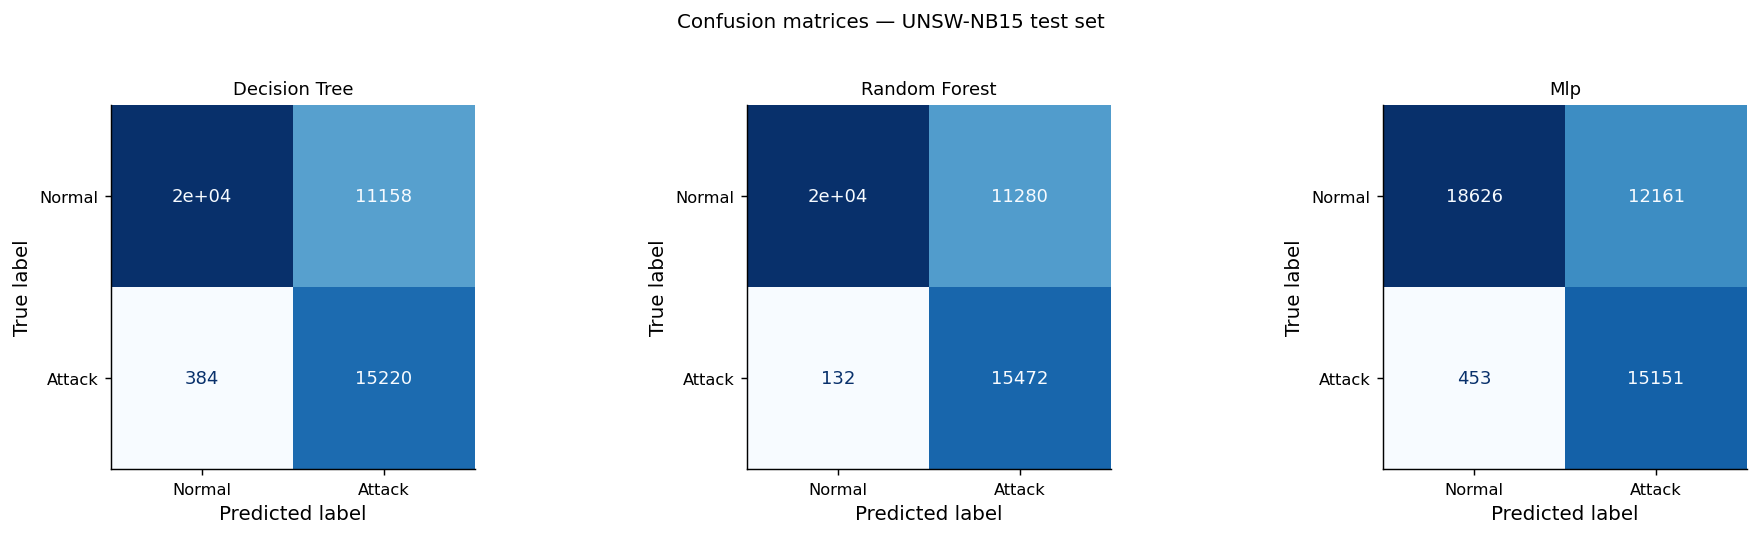


── roc_curves ──


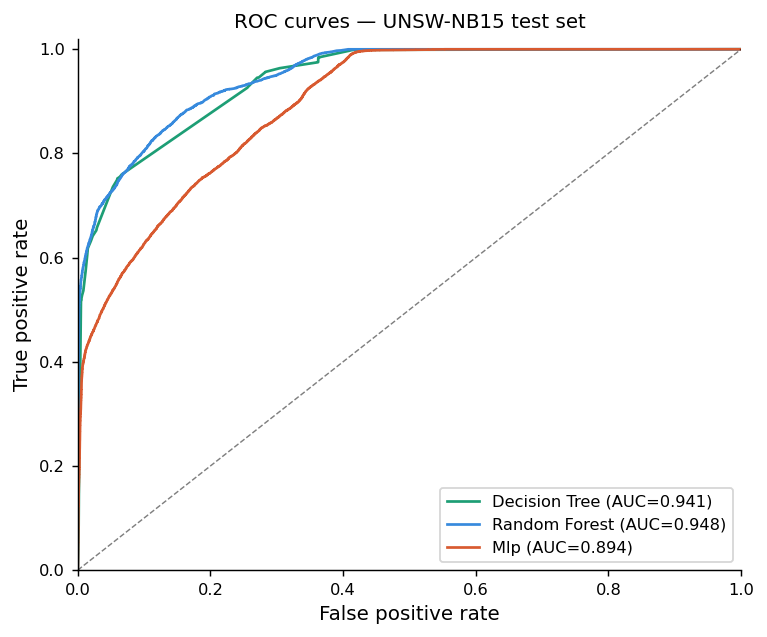


── metric_comparison ──


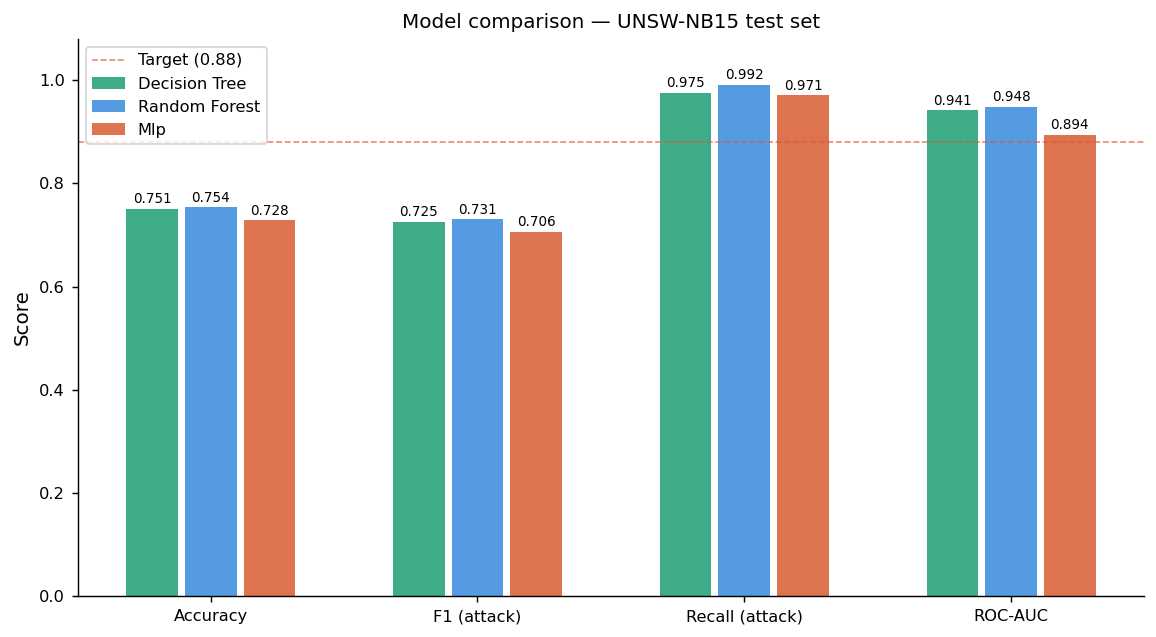


── feature_importance ──


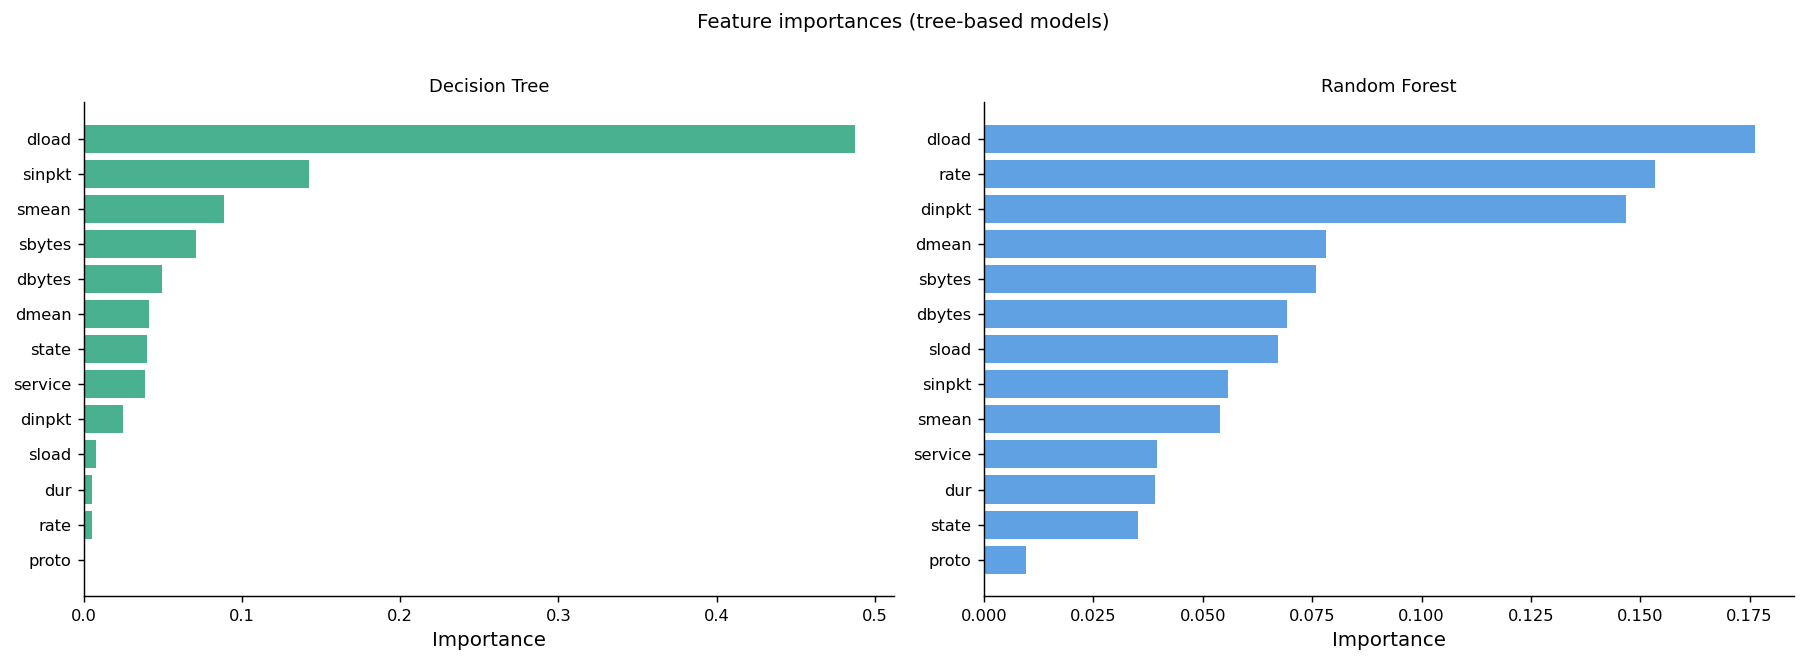


── overfit_diagnostic ──


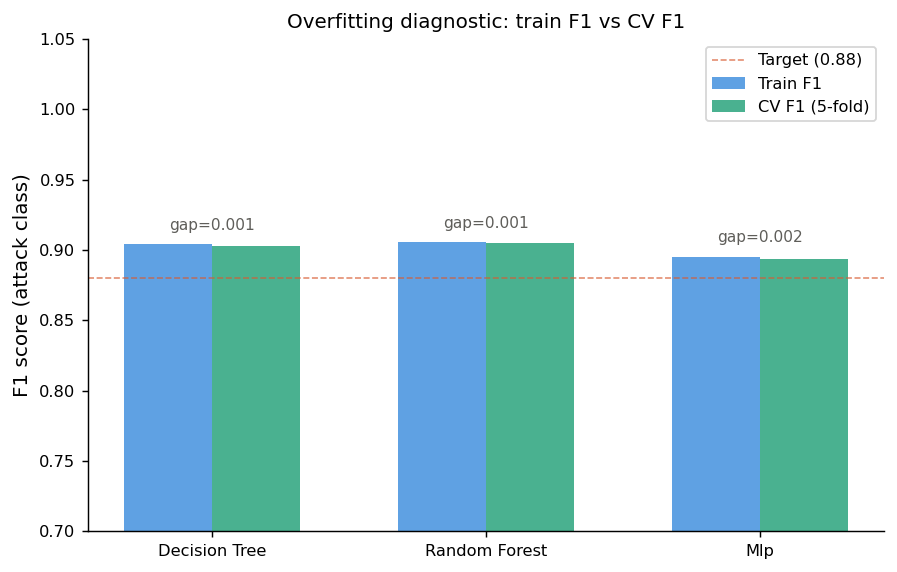

In [8]:
from IPython.display import display, Image
for name, path in plot_paths.items():
    print(f'\n── {name} ──')
    display(Image(path, width=750))

## 6. Overfit Diagnostic — Gate Check for Phase 3
Before proceeding to BoT-IoT fine-tuning, both conditions must be true for the MLP:
- F1 (attack) ≥ 0.88
- Overfit gap (train F1 − CV F1) ≤ 0.05

In [9]:
mlp_r = results['results']['mlp']

f1_ok  = mlp_r['f1_attack'] >= 0.88
gap_ok = mlp_r['overfit_gap_f1'] <= 0.05

print('── Phase 3 Gate Check (MLP) ──')
print(f"  F1 attack:    {mlp_r['f1_attack']:.4f}   {'PASS' if f1_ok  else 'FAIL — retune hidden layers or regularisation'}")
print(f"  Overfit gap:  {mlp_r['overfit_gap_f1']:.4f}   {'PASS' if gap_ok else 'FAIL — increase alpha or reduce layer size'}")
print()
if f1_ok and gap_ok:
    print('GATE PASSED. Proceed to Phase 3 (BoT-IoT fine-tuning).')
else:
    print('GATE FAILED. Fix the issues above before fine-tuning on BoT-IoT.')
    print('Fine-tuning a poor UNSW model will compound errors, not fix them.')

── Phase 3 Gate Check (MLP) ──
  F1 attack:    0.7061   FAIL — retune hidden layers or regularisation
  Overfit gap:  0.0016   PASS

GATE FAILED. Fix the issues above before fine-tuning on BoT-IoT.
Fine-tuning a poor UNSW model will compound errors, not fix them.


## 7. Phase 2 Summary

In [10]:
summary_path = METRICS_DIR / 'phase2_results.json'
with open(summary_path) as f:
    saved = json.load(f)
print(json.dumps(saved, indent=2))

{
  "phase": "2 \u2014 Model Training (UNSW-NB15)",
  "features": [
    "dur",
    "proto",
    "service",
    "state",
    "sbytes",
    "dbytes",
    "rate",
    "sload",
    "dload",
    "sinpkt",
    "dinpkt",
    "smean",
    "dmean"
  ],
  "n_features": 13,
  "train_size": 89090,
  "test_size": 46391,
  "results": {
    "decision_tree": {
      "model": "decision_tree",
      "accuracy": 0.7512,
      "f1_attack": 0.7251,
      "precision": 0.577,
      "recall_attack": 0.9754,
      "roc_auc": 0.9414,
      "confusion_matrix": [
        [
          19629,
          11158
        ],
        [
          384,
          15220
        ]
      ],
      "tp": 15220,
      "tn": 19629,
      "fp": 11158,
      "fn": 384,
      "false_negative_rate": 0.0246,
      "meets_target": false,
      "cv_accuracy_mean": 0.9022,
      "cv_accuracy_std": 0.0017,
      "cv_f1_mean": 0.9026,
      "cv_f1_std": 0.0017,
      "train_accuracy_mean": 0.9034,
      "train_f1_mean": 0.9039,
      "overfit

---
**Next:** `03_botiot_finetune.ipynb` — Phase 3: domain adaptation on NF-BoT-IoT.

**Before proceeding:**
1. MLP must pass the gate check above.
2. Note which features have near-zero importance (plot 09) — these can be dropped in Phase 3 to further reduce model size.
3. Check the overfit diagnostic plot (plot 10) — any gap > 0.05 must be addressed here, not in Phase 3.